<a href="https://colab.research.google.com/github/arunakochi1971-sys/Machine-Learning/blob/main/exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
classification_report,
accuracy_score,
confusion_matrix
)

import seaborn as sns

In [2]:
(X_train_full, y_train_full), (X_test_full, y_test_full) = \
fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
class_names = [
'T-shirt/top',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',

'Bag',
'Ankle boot'
]

print(f"Full Training set shape: {X_train_full.shape}")
print(f"Full Test set shape: {X_test_full.shape}")

Full Training set shape: (60000, 28, 28)
Full Test set shape: (10000, 28, 28)


In [5]:
_, X_train_sub, _, y_train_sub = train_test_split(
X_train_full,
y_train_full,
test_size=10000,
stratify=y_train_full,
random_state=42
)

In [6]:
_, X_test_sub, _, y_test_sub = train_test_split(
X_test_full,
y_test_full,
test_size=2000,
stratify=y_test_full,
random_state=42
)

In [7]:
X_train_flat = X_train_sub.reshape(
X_train_sub.shape[0], -1
)

X_test_flat = X_test_sub.reshape(
X_test_sub.shape[0], -1
)

In [9]:
X_train_norm = X_train_flat / 255.0
X_test_norm = X_test_flat / 255.0

print(
f"\nSubsampled & Processed Training Shape: "
f"{X_train_norm.shape}"
)

print(
f"Subsampled & Processed Testing Shape: "
f"{X_test_norm.shape}"
)


Subsampled & Processed Training Shape: (10000, 784)
Subsampled & Processed Testing Shape: (2000, 784)


In [11]:
k_values = [1, 3, 5, 7, 9, 11, 15]

accuracies = []
inference_times = []

print("Starting KNN Experiments...\n")

for k in k_values:

    print(f"Evaluating K = {k}...")

    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',
        p=2,
        n_jobs=-1
    )

    knn.fit(X_train_norm, y_train_sub)

Starting KNN Experiments...

Evaluating K = 1...
Evaluating K = 3...
Evaluating K = 5...
Evaluating K = 7...
Evaluating K = 9...
Evaluating K = 11...
Evaluating K = 15...


In [13]:
start_time = time.time()

y_pred = knn.predict(X_test_norm)

end_time = time.time()

elapsed_time = end_time - start_time

acc = accuracy_score(y_test_sub, y_pred)

accuracies.append(acc)
inference_times.append(elapsed_time)

print(
f"-> Accuracy: {acc:.4f} | "
f"Inference Time: {elapsed_time:.2f} seconds\n"
)

-> Accuracy: 0.8040 | Inference Time: 1.91 seconds



In [15]:
best_k_idx = np.argmax(accuracies)
best_k = k_values[best_k_idx]

print(f"Optimal configuration found at K = {best_k}")

Optimal configuration found at K = 1


In [16]:
best_knn = KNeighborsClassifier(
n_neighbors=best_k,
n_jobs=-1
)

best_knn.fit(X_train_norm, y_train_sub)

y_pred_best = best_knn.predict(X_test_norm)

In [18]:
print("\n### Classification Report ###")

print(
    classification_report(
        y_test_sub,
        y_pred_best,
        target_names=class_names
    )
)


### Classification Report ###
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.78      0.77       200
     Trouser       0.98      0.97      0.98       200
    Pullover       0.63      0.76      0.69       200
       Dress       0.87      0.81      0.84       200
        Coat       0.68      0.64      0.66       200
      Sandal       1.00      0.76      0.86       200
       Shirt       0.51      0.51      0.51       200
     Sneaker       0.85      0.94      0.89       200
         Bag       0.97      0.93      0.95       200
  Ankle boot       0.84      0.94      0.89       200

    accuracy                           0.80      2000
   macro avg       0.81      0.80      0.80      2000
weighted avg       0.81      0.80      0.80      2000



In [19]:
cm = confusion_matrix(

y_test_sub,
y_pred_best
)

plt.figure(figsize=(10, 8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

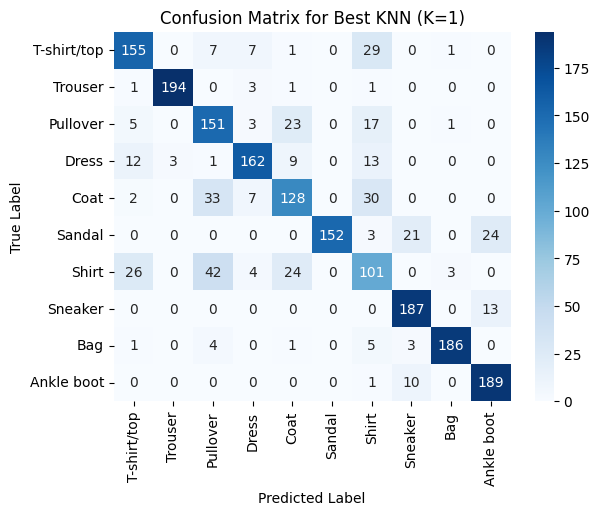

In [21]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    f'Confusion Matrix for Best KNN (K={best_k})'
)

plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()